# Creating a minimal Neural Network for classification

Note: Content adapted from: https://cs231n.github.io/


In this section we’ll walk through a complete implementation of a toy Neural Network in 2 dimensions. We’ll first implement a simple linear classifier and then extend the code to a 2-layer Neural Network. As we’ll see, this extension is surprisingly simple and very few changes are necessary.

In [1]:
# A bit of setup
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading extenrnal modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

## Generating some data
Lets generate a classification dataset that is not easily linearly separable. Our favorite example is the spiral dataset, which can be generated as follows:

(-1.0, 1.0)

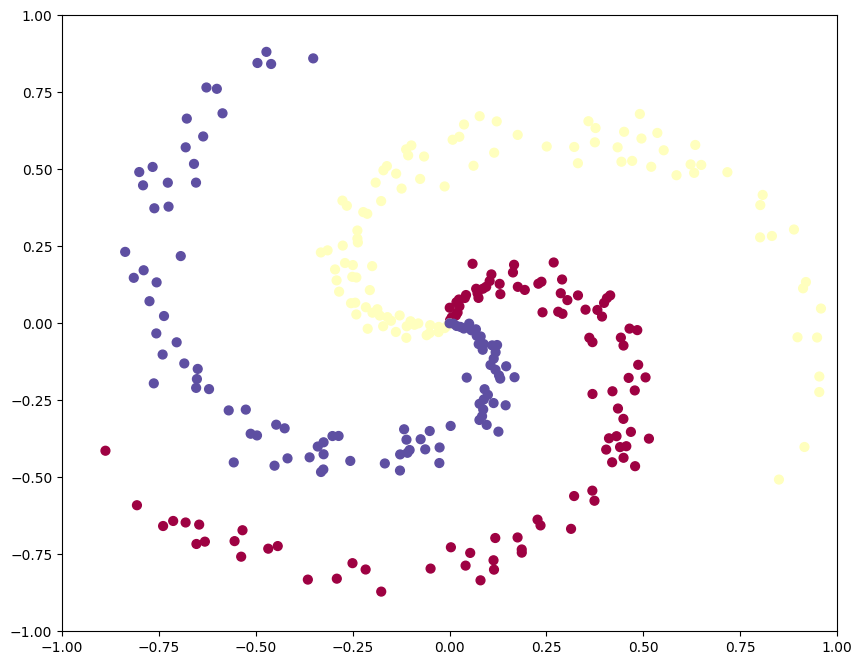

In [2]:
np.random.seed(0)
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D))
y = np.zeros(N*K, dtype='uint8')
for j in range(K):
    ix = range(N*j,N*(j+1))
    r = np.linspace(0.0,1,N) # radius
    t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
    X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
    y[ix] = j
fig = plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim([-1,1])
plt.ylim([-1,1])
#fig.savefig('spiral_raw.png')

The toy spiral data consists of three classes (blue, red, yellow) that are not linearly separable.

Normally we would want to preprocess the dataset so that each feature has zero mean and unit standard deviation, but in this case the features are already in a nice range from -1 to 1, so we skip this step.

## Training a Softmax Linear Classifier

We will use the Softmax activation function ($\sigma(\mathbf{z})_i = \frac{e^{z_i}}{\sum_{j=1}^K e^{z_j}}$) to convert the classifier output into probabilities and the [Cross-Entropy Loss](https://towardsdatascience.com/cross-entropy-loss-function-f38c4ec8643e) ($L(x,y) = -\sum_{j} y_j \log p(c_j|x)$) to calculate the loss for a given set of weights W.

In [3]:
from math import log2

#Numpy version of Softmax function
def softmax_numpy(scores):
    return np.exp(scores) / np.sum(np.exp(scores), axis=1, keepdims=True) # [N x K]

# calculate average cross-entropy loss
def cross_entropy_loss(probs, y):
    corect_logprobs = -np.log(probs[range(num_examples),y])
    loss = np.sum(corect_logprobs)/num_examples
    return loss


**Softmax Activation Function**: For a given class score vector $z$, the softmax function calculates the probability $p_i$ for each class $i$ as follows:

$$p_i = \frac{exp(z_i)}{ Σ_j exp(z_j)}$$

**Cross-Entropy Loss**: The cross-entropy loss for a single example with true label $y$ and predicted probabilities $p$ is given by:

$$L = - Σ_i y_i \times log(p_i)$$

where $p_i$ is the predicted probability for class $i$.

If the true label $y$ is one-hot encoded, then the cross-entropy loss simplifies to:

$$L = -log(p_y)$$

where $p_y$ is the predicted probability for the true class $y$.

Now, we want to compute the derivative of the loss L with respect to the softmax input (class scores) $z$. Let's denote this derivative as $dL/dz$. For simplicity, let's focus on the derivative of the loss with respect to a single class score $z_i$:

- If i is not the true class label (i ≠ y), then the derivative $dL/dz_i$ is equal to the softmax probability $p_i$ for that class.

$$
\frac{dL}{dz_i} = \frac{d(-log(p_y))}{dz_i} = - \frac{1}{p_y} \times \frac{dp_y}{dz_i}
        = - \frac{1}{p_y} \times (-p_y \times p_i)
        = p_i
$$
Therefore we set: $dscores = probs$

- If $i$ is the true class label (i = y), then the derivative $dL/dz_i$ is equal to $p_i - 1$.

$$
\frac{dL}{dz_i} = \frac{d(-log(p_y))}{dz_i} = - \frac{1}{p_y} \times \frac{dp_y}{dz_i}
        = - \frac{1}{p_y} \times p_y \times (1 - p_i)
        = p_i - 1
$$

 Therefore we set: $dscores[range(N),y] -= 1$

- Finally, we divide each element in the dscores matrix by the total number of examples (N). This step is necessary because we are computing the average gradient across all examples, as we used the average cross-entropy loss in the loss calculation. $dscores = dscores/N$


In [4]:
# Train a Linear Classifier

# initialize parameters randomly
W = 0.01 * np.random.randn(D,K)
b = np.zeros((1,K))

# some hyperparameters
step_size = 1e-0

# gradient descent loop
num_examples = X.shape[0]
for i in range(200):

    # evaluate class scores, [N x K]
    scores = np.dot(X, W) + b 

    # compute the class probabilities using Softmax activation
    probs = softmax_numpy(scores)

    # compute the loss: average cross-entropy loss
    loss = cross_entropy_loss(probs, y)
    
    if i % 10 == 0:
        print("iteration {:d}: loss {:f}".format(i, loss))

    # compute the gradient on scores
    dscores = probs                         # First, set dscores to be equal to the probabilities
    dscores[range(num_examples),y] -= 1     # Then, subtract 1 from the probability corresponding to the true class label
    dscores /= num_examples                 # Divide each element in dscores by the total number of examples

    # backpropate the gradient to the parameters (W,b)
    dW = np.dot(X.T, dscores)
    db = np.sum(dscores, axis=0, keepdims=True)

    # perform a parameter update
    W += -step_size * dW
    b += -step_size * db

iteration 0: loss 1.096919
iteration 10: loss 0.915808
iteration 20: loss 0.847970
iteration 30: loss 0.817109
iteration 40: loss 0.801059
iteration 50: loss 0.791931
iteration 60: loss 0.786406
iteration 70: loss 0.782907
iteration 80: loss 0.780613
iteration 90: loss 0.779070
iteration 100: loss 0.778009
iteration 110: loss 0.777268
iteration 120: loss 0.776744
iteration 130: loss 0.776368
iteration 140: loss 0.776097
iteration 150: loss 0.775899
iteration 160: loss 0.775754
iteration 170: loss 0.775648
iteration 180: loss 0.775569
iteration 190: loss 0.775510


We see that we’ve converged to something after about 190 iterations. We can evaluate the training set accuracy:

In [5]:
# evaluate training set accuracy
scores = np.dot(X, W) + b
predicted_class = np.argmax(scores, axis=1)
print("training accuracy: {:.2f}".format(np.mean(predicted_class == y)))

training accuracy: 0.49


This prints __49%__. Not very good at all, but also not surprising given that the dataset is constructed so it is not linearly separable. 

We can also plot the learned decision boundaries:

(-1.8712034092398278, 1.8687965907601756)

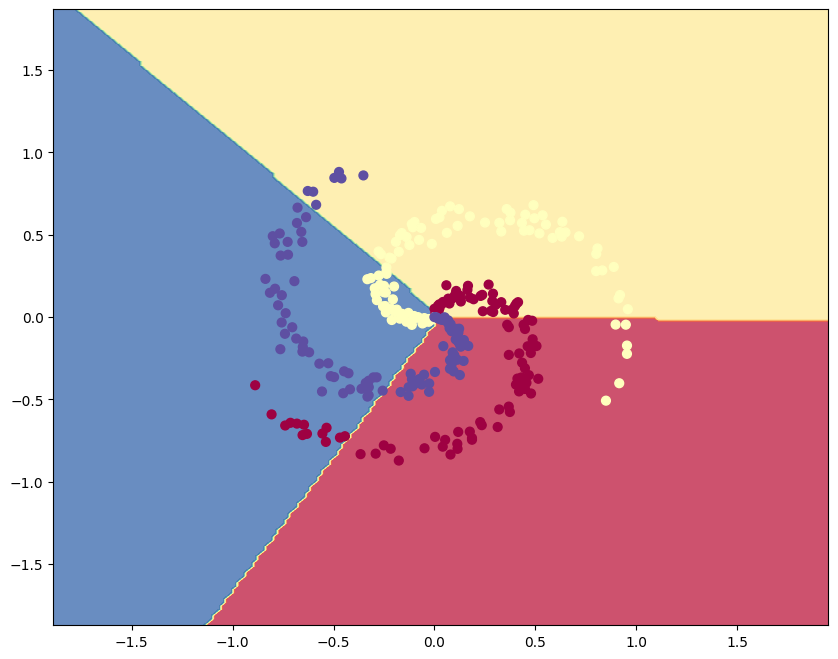

In [6]:
# plot the resulting classifier
h = 0.02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = np.dot(np.c_[xx.ravel(), yy.ravel()], W) + b
Z = np.argmax(Z, axis=1)
Z = Z.reshape(xx.shape)
fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
#fig.savefig('spiral_linear.png')

Linear classifier fails to learn the toy spiral dataset.

## Training a Neural Network

Clearly, a linear classifier is inadequate for this dataset and we would like to use a Neural Network. One additional hidden layer will suffice for this toy data. We will now need two sets of weights and biases (for the first and second layers):

In [7]:
# initialize parameters randomly
h = 100 # size of hidden layer
W = 0.01 * np.random.randn(D,h)
b = np.zeros((1,h))
W2 = 0.01 * np.random.randn(h,K)
b2 = np.zeros((1,K))

# some hyperparameters
step_size = 1e-0

# gradient descent loop
num_examples = X.shape[0]
for i in range(3000):

    # evaluate class scores, [N x K]
    hidden_layer = np.maximum(0, np.dot(X, W) + b) # note, ReLU activation
    scores = np.dot(hidden_layer, W2) + b2

    # compute the class probabilities using Softmax activation
    probs = softmax_numpy(scores)

    # compute the loss: average cross-entropy loss
    loss = cross_entropy_loss(probs, y)
    if i % 200 == 0:
        print("iteration {:d}: loss {:.2f}".format(i, loss))

    # compute the gradient on scores
    dscores = probs
    dscores[range(num_examples),y] -= 1
    dscores /= num_examples

    # backpropate the gradient to the parameters
    # first backprop into parameters W2 and b2
    dW2 = np.dot(hidden_layer.T, dscores)
    db2 = np.sum(dscores, axis=0, keepdims=True)
    
    # next backprop into hidden layer
    dhidden = np.dot(dscores, W2.T)
    
    # backprop the ReLU non-linearity
    dhidden[hidden_layer <= 0] = 0
    
    # finally into W,b
    dW = np.dot(X.T, dhidden)
    db = np.sum(dhidden, axis=0, keepdims=True)

    # perform a parameter update
    W += -step_size * dW
    b += -step_size * db
    W2 += -step_size * dW2
    b2 += -step_size * db2

iteration 0: loss 1.10
iteration 200: loss 0.73
iteration 400: loss 0.36
iteration 600: loss 0.42
iteration 800: loss 0.37
iteration 1000: loss 0.11
iteration 1200: loss 0.09
iteration 1400: loss 0.07
iteration 1600: loss 0.06
iteration 1800: loss 0.06
iteration 2000: loss 0.05
iteration 2200: loss 0.05
iteration 2400: loss 0.04
iteration 2600: loss 0.04
iteration 2800: loss 0.04


The training accuracy is now:

In [8]:
# evaluate training set accuracy
hidden_layer = np.maximum(0, np.dot(X, W) + b)
scores = np.dot(hidden_layer, W2) + b2
predicted_class = np.argmax(scores, axis=1)
print("training accuracy: {:.2f}".format(np.mean(predicted_class == y)))

training accuracy: 0.99


Which prints __99%__!. We can also visualize the decision boundaries:

(-1.8712034092398278, 1.8687965907601756)

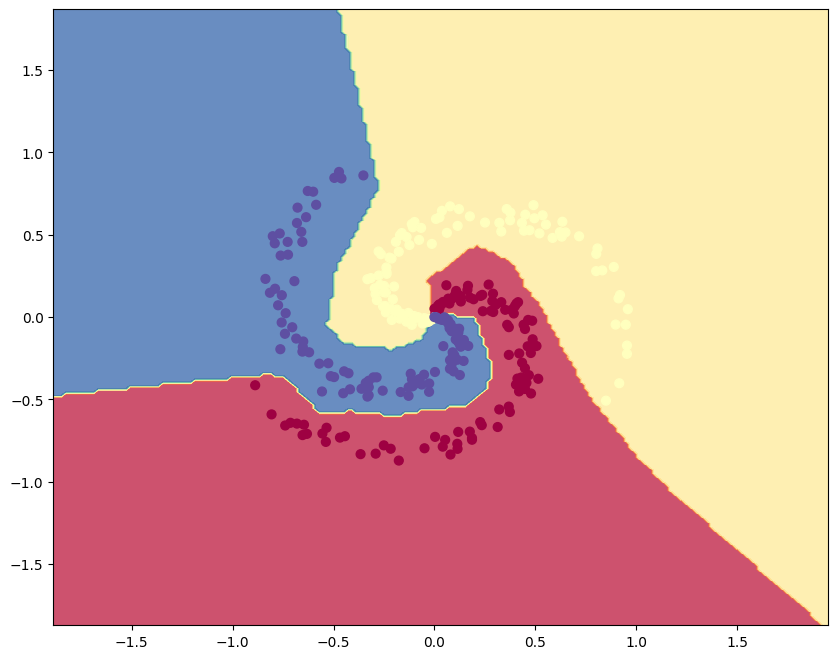

In [9]:
# plot the resulting classifier
h = 0.02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = np.dot(np.maximum(0, np.dot(np.c_[xx.ravel(), yy.ravel()], W) + b), W2) + b2
Z = np.argmax(Z, axis=1)
Z = Z.reshape(xx.shape)
fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
#fig.savefig('spiral_net.png')

Neural Network classifier crushes the spiral dataset.

### Tensorflow Implementation

The above neural network can be implemeted using the Tensorflow and Keras libraries with only a few lines of code.

In [10]:
# Force TensorFlow to use the CPU in environments with a broken CUDA/XLA toolchain.
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

# Import Tensorflow 2.0
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
tf.config.optimizer.set_jit(False)

# Initialize a Sequential model. Sequential means that layers are added in sequence one after the other.
with tf.device('/CPU:0'):
    model = tf.keras.models.Sequential()

    # Define the number of neurons (100) and the activation function (ReLU) for the first fully connected (Dense) layer.
    # The input dimension (input_dim) should be set to the dimensionality of the input vector.
    model.add(layers.Dense(100, input_dim=D, activation='relu'))

    # Define the second Dense layer to output the classification probabilities.
    # The number of neurons in the last layer is the same as the number of classes (K)
    model.add(layers.Dense(K, activation='softmax'))

    # Compile the model. Here we specify the type of gradient descent algorithm to use,
    # the loss function, and the types of metrics that we want to calculate for each epoch
    model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=1e-0),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
model.summary()

2026-04-27 10:21:40.563285: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777303300.580315  473800 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777303300.585297  473800 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777303300.597104  473800 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777303300.597120  473800 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777303300.597122  473800 computation_placer.cc:177] computation placer alr

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           303 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 603 (2.36 KB)

 Trainable params: 603 (2.36 KB)

 Non-trainable params: 0 (0.00 B)

Let's train the model

In [11]:
EPOCHS=500
with tf.device('/CPU:0'):
    history = model.fit(X, y, epochs=EPOCHS, verbose=0)

We can vizualize the learning history to see how our model converged.

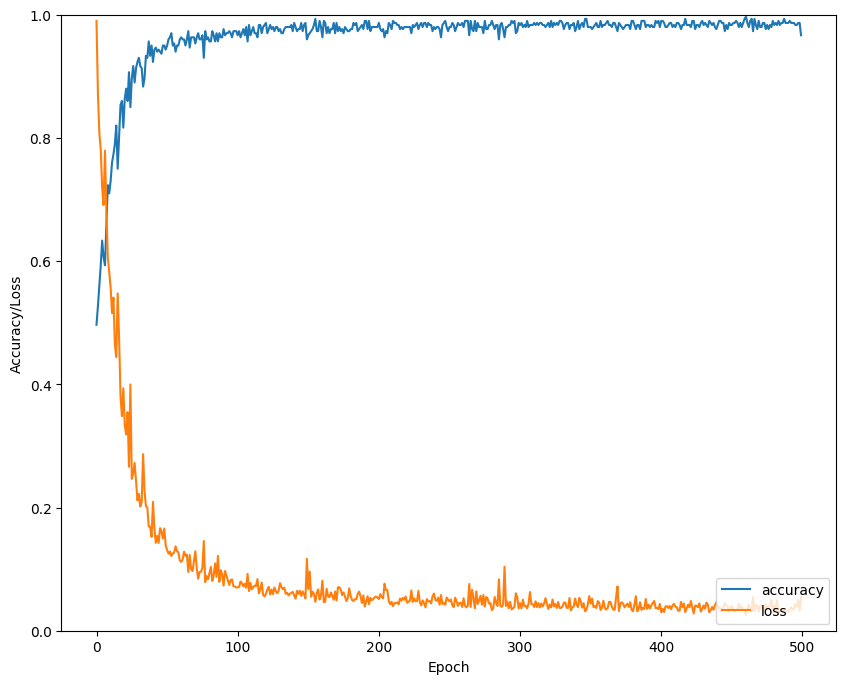

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['loss'], label = 'loss')
plt.xlabel('Epoch')
plt.ylabel('Accuracy/Loss')
plt.ylim([0.0, 1])
plt.legend(loc='lower right')

Let's now classify the instances of the training set

In [13]:
with tf.device('/CPU:0'):
    scores = model.predict(X, verbose=0)
predicted_class = np.argmax(scores, axis=1)
print("training accuracy: {:.2f}".format(np.mean(predicted_class == y)))

training accuracy: 0.99


We will see more details about Tensorflow and its functionality in the next Jupyter notebook, where we are going to introduce Convolutional Neural Networks.

## Adding Regularization

A regularization term can be added to the loss calculation to prevent overfitting. This regularization add e penalty to the total sum of weights to keep the weights low. 

The cost function now becomes: $C = C_0 + \lambda \sum w^2$

In [14]:
# initialize parameters randomly
h = 100 # size of hidden layer
W = 0.01 * np.random.randn(D,h)
b = np.zeros((1,h))
W2 = 0.01 * np.random.randn(h,K)
b2 = np.zeros((1,K))

# some hyperparameters
step_size = 1e-0
reg = 1e-3 # regularization strength (value of parameter lambda)

# gradient descent loop
num_examples = X.shape[0]
for i in range(10000):

    # evaluate class scores, [N x K]
    hidden_layer = np.maximum(0, np.dot(X, W) + b) # note, ReLU activation
    scores = np.dot(hidden_layer, W2) + b2

    # compute the class probabilities using Softmax activation
    probs = softmax_numpy(scores)

    # compute the loss: average cross-entropy loss
    data_loss = cross_entropy_loss(probs, y)
    
    # introduce regularization to prevent overfitting
    reg_loss = 0.5*reg*np.sum(W*W) + 0.5*reg*np.sum(W2*W2)
    
    loss = data_loss + reg_loss
    if i % 1000 == 0:
        print("iteration {:d}: loss {:.2f}".format(i, loss))

    # compute the gradient on scores
    dscores = probs
    dscores[range(num_examples),y] -= 1
    dscores /= num_examples

    # backpropate the gradient to the parameters
    # first backprop into parameters W2 and b2
    dW2 = np.dot(hidden_layer.T, dscores)
    db2 = np.sum(dscores, axis=0, keepdims=True)
    # next backprop into hidden layer
    dhidden = np.dot(dscores, W2.T)
    # backprop the ReLU non-linearity
    dhidden[hidden_layer <= 0] = 0
    # finally into W,b
    dW = np.dot(X.T, dhidden)
    db = np.sum(dhidden, axis=0, keepdims=True)

    # add regularization gradient contribution
    dW2 += reg * W2
    dW += reg * W

    # perform a parameter update
    W += -step_size * dW
    b += -step_size * db
    W2 += -step_size * dW2
    b2 += -step_size * db2

iteration 0: loss 1.10
iteration 1000: loss 0.28
iteration 2000: loss 0.27
iteration 3000: loss 0.25
iteration 4000: loss 0.25
iteration 5000: loss 0.25
iteration 6000: loss 0.25
iteration 7000: loss 0.25
iteration 8000: loss 0.25
iteration 9000: loss 0.25


The training accuracy is now:

In [15]:
# evaluate training set accuracy
hidden_layer = np.maximum(0, np.dot(X, W) + b)
scores = np.dot(hidden_layer, W2) + b2
predicted_class = np.argmax(scores, axis=1)
print("training accuracy: {:.2f}".format(np.mean(predicted_class == y)))

training accuracy: 0.98


As we can notice, by adding regularization the accuracy when classifying the training data drops a little bit, but it could make a positive difference if we were to evaluate on some new test data by being able to generalize better.

## Summary

We’ve worked with a toy 2D dataset and trained both a linear network and a 2-layer Neural Network. We saw that the change from a linear classifier to a Neural Network involves very few changes in the code. The score function changes its form (1 line of code difference), and the backpropagation changes its form (we have to perform one more round of backprop through the hidden layer to the first layer of the network).